# 03 — RoBERTa-base PEFT/LoRA Fine-Tuning with Keras

This Kaggle-ready notebook parameter-efficiently fine-tunes `roberta_base_en` with built-in KerasHub LoRA for balanced five-class Amazon review rating prediction. It uses Keras 3 + KerasHub, TensorFlow GPU distribution, mixed precision, AdamW, linear warmup followed by cosine decay, robust callbacks, resumable training state, periodic step checkpoints, and complete validation reporting.

**Do not use the official test set for model selection.** Labels are mapped from `1..5` to `0..4` for training and converted back for reports.

## Kaggle setup

1. Enable a GPU accelerator in Notebook settings.
2. Add the processed dataset created by `02_preprocessing.ipynb`.
3. Recommended offline-safe setup: choose **Add Input → Models**, search for `keras/roberta`, and attach the Keras model `roberta_base_en` before starting `Save & Run All`. The notebook automatically discovers its local preset under `/kaggle/input`.
4. If no local model is attached, enable Internet so the notebook can fall back to `hf://FacebookAI/roberta-base`.
5. If automatic dataset discovery finds more than one candidate, set `KAGGLE_DATASET_SLUG` in the configuration cell.

The notebook auto-discovers the attached `train.csv` and `validation.csv`; the recommended dataset is `bert_balanced_50000_per_class` (240,000 train and 10,000 validation rows).

In [1]:
import os
import subprocess
import sys

os.environ['KERAS_BACKEND'] = 'tensorflow'

try:
    import keras_hub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-hub'])
    import keras_hub

import keras
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('KerasHub:', keras_hub.__version__)
print('scikit-learn:', sklearn.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
KerasHub: 0.26.0
scikit-learn: 1.6.1


## Configuration — change paths or experiment settings only here

In [2]:
from pathlib import Path

# Local attached Kaggle Model is preferred; HF is the online fallback.
MODEL_PRESET = 'hf://FacebookAI/roberta-base'
LOCAL_MODEL_PRESET = '/kaggle/input/models/keras/roberta/keras/roberta_base_en/3'  # Optional explicit /kaggle/input/... preset directory.
NUM_CLASSES = 5
MAX_LENGTH = 256  # Preserve substantially more review evidence than 128 tokens.
EPOCHS = 5  # EarlyStopping still restores the best validation epoch.
PER_REPLICA_BATCH_SIZE = 8  # Safe default for RoBERTa at length 256 on a 16 GB P100.
USE_MULTI_GPU = False  # Keep False for TF 2.20 + KerasHub 0.26 LoRA stability.
LORA_RANK = 16
PEAK_LEARNING_RATE = 5e-5  # More stable for RoBERTa LoRA than the previous 1e-4.
END_LEARNING_RATE_RATIO = 0.10
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
RANDOM_STATE = 42
CHECKPOINT_EVERY_BATCHES = 500

# Set this when auto-discovery is ambiguous, e.g. 'amazon-balanced-bert-data'.
KAGGLE_DATASET_SLUG = 'datasets/maslri/balanced-50000/bert_balanced_50000_per_class'

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/roberta_keras_lora')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
BACKUP_DIR = OUTPUT_DIR / 'training_backup'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [OUTPUT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

## GPU, mixed precision, and distributed strategy

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError('No GPU detected. Enable a Kaggle GPU accelerator before training.')

keras.mixed_precision.set_global_policy('mixed_float16')

# TF 2.20 + KerasHub 0.26 can fail with a bool AddN reduction when
# PipelineModel/LoRA is trained under MirroredStrategy on Kaggle T4x2.
# The default strategy reliably uses GPU:0 without cross-replica reduction.
if USE_MULTI_GPU:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync

print('GPUs:', gpus)
print('Strategy:', type(strategy).__name__)
print('Replicas:', strategy.num_replicas_in_sync)
print('Global batch size:', GLOBAL_BATCH_SIZE)
print('Mixed precision policy:', keras.mixed_precision.global_policy())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Replicas: 1
Global batch size: 8
Mixed precision policy: <DTypePolicy "mixed_float16">


## Locate and validate the Kaggle dataset

In [4]:
def find_dataset_file(filename):
    search_root = INPUT_ROOT / KAGGLE_DATASET_SLUG if KAGGLE_DATASET_SLUG else INPUT_ROOT
    candidates = sorted(search_root.rglob(filename))
    valid_candidates = []
    for path in candidates:
        try:
            columns = pd.read_csv(path, nrows=2).columns
            if {'overall', 'model_input'}.issubset(columns):
                valid_candidates.append(path)
        except Exception:
            continue
    if len(valid_candidates) != 1:
        raise FileNotFoundError(
            f'Expected exactly one valid {filename}; found {valid_candidates}. '
            'Set KAGGLE_DATASET_SLUG explicitly.'
        )
    return valid_candidates[0]

TRAIN_PATH = find_dataset_file('train.csv')
VALIDATION_PATH = find_dataset_file('validation.csv')
print('Train:', TRAIN_PATH)
print('Validation:', VALIDATION_PATH)

Train: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/train.csv
Validation: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/validation.csv


In [5]:
usecols = ['overall', 'model_input']
train_df = pd.read_csv(TRAIN_PATH, usecols=usecols, low_memory=False)
validation_df = pd.read_csv(VALIDATION_PATH, usecols=usecols, low_memory=False)

for name, frame in [('train', train_df), ('validation', validation_df)]:
    assert frame['overall'].between(1, 5).all(), f'Invalid labels in {name}'
    assert frame['model_input'].notna().all(), f'Missing text in {name}'
    assert frame['model_input'].str.strip().ne('').all(), f'Empty text in {name}'
    print(name, frame.shape, frame['overall'].value_counts().sort_index().to_dict())

train_text = train_df['model_input'].astype(str).to_numpy()
validation_text = validation_df['model_input'].astype(str).to_numpy()
train_labels = (train_df['overall'].to_numpy(dtype='int32') - 1)
validation_labels = (validation_df['overall'].to_numpy(dtype='int32') - 1)

train (240000, 2) {1: 48000, 2: 48000, 3: 48000, 4: 48000, 5: 48000}
validation (10000, 2) {1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000}


## Build efficient `tf.data` pipelines

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
options = tf.data.Options()
options.experimental_deterministic = True

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_text, train_labels))
    .shuffle(len(train_text), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    .batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
    .with_options(options)
)
validation_ds = (
    tf.data.Dataset.from_tensor_slices((validation_text, validation_labels))
    .batch(GLOBAL_BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .with_options(options)
)

STEPS_PER_EPOCH = len(train_text) // GLOBAL_BATCH_SIZE
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_RATIO))
DECAY_STEPS = max(1, TOTAL_STEPS - WARMUP_STEPS)
print({
    'steps_per_epoch': STEPS_PER_EPOCH,
    'total_steps': TOTAL_STEPS,
    'warmup_steps': WARMUP_STEPS,
    'decay_steps': DECAY_STEPS,
})

I0000 00:00:1785862281.215764      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


{'steps_per_epoch': 30000, 'total_steps': 150000, 'warmup_steps': 15000, 'decay_steps': 135000}


## RoBERTa-base PEFT/LoRA, AdamW, warmup, and cosine decay

KerasHub LoRA freezes the pretrained RoBERTa backbone and injects trainable low-rank adapters into the query/value attention projections. The classification head remains trainable. Rank 16 provides more adaptation capacity than very small ranks while still training far below 1% of the full backbone parameters.

For single-label multiclass classification, micro F1 equals accuracy. The metric is named `micro_f1` so checkpoint selection matches the official objective. Macro and weighted F1 are calculated after prediction for diagnostics.

In [7]:
learning_rate = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    warmup_target=PEAK_LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    decay_steps=DECAY_STEPS,
    alpha=END_LEARNING_RATE_RATIO,
)

def resolve_roberta_preset():
    if LOCAL_MODEL_PRESET:
        local_path = Path(LOCAL_MODEL_PRESET)
        if not (local_path / 'config.json').exists():
            raise FileNotFoundError(f'No config.json in LOCAL_MODEL_PRESET={local_path}')
        return str(local_path)

    local_candidates = []
    for config_path in INPUT_ROOT.rglob('config.json'):
        candidate = config_path.parent
        candidate_text = str(candidate).lower()
        has_tokenizer = (candidate / 'tokenizer.json').exists()
        if 'roberta' in candidate_text and has_tokenizer:
            local_candidates.append(candidate)

    local_candidates = sorted(set(local_candidates))
    if len(local_candidates) == 1:
        print('Using attached offline Kaggle Model preset.')
        return str(local_candidates[0])
    if len(local_candidates) > 1:
        raise RuntimeError(
            f'Multiple local RoBERTa presets found: {local_candidates}. '
            'Set LOCAL_MODEL_PRESET explicitly.'
        )

    import socket
    try:
        socket.gethostbyname('huggingface.co')
    except OSError as error:
        raise RuntimeError(
            'No attached RoBERTa preset was found and Kaggle Internet/DNS is disabled. '
            'Use Add Input -> Models -> keras/roberta -> roberta_base_en, '
            'then restart and run the notebook again.'
        ) from error
    print('No local preset found; using the online Hugging Face fallback.')
    return MODEL_PRESET

effective_model_preset = resolve_roberta_preset()
print('Loading preset:', effective_model_preset)

with strategy.scope():
    model = keras_hub.models.RobertaTextClassifier.from_preset(
        effective_model_preset,
        num_classes=NUM_CLASSES,
        activation=None,
        dropout=0.1,
    )
    model.preprocessor.sequence_length = MAX_LENGTH
    model.backbone.enable_lora(rank=LORA_RANK)

    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-6,
        global_clipnorm=1.0,
    )
    optimizer.exclude_from_weight_decay(var_names=['bias', 'beta', 'gamma'])
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='micro_f1')],
        jit_compile=False,
    )

trainable_parameters = int(sum(np.prod(variable.shape) for variable in model.trainable_weights))
total_parameters = int(sum(np.prod(variable.shape) for variable in model.weights))
trainable_percentage = 100.0 * trainable_parameters / total_parameters

print(f'Trainable parameters: {trainable_parameters:,}')
print(f'Total parameters: {total_parameters:,}')
print(f'Trainable percentage: {trainable_percentage:.4f}%')
model.summary()

Loading preset: /kaggle/input/models/keras/roberta/keras/roberta_base_en/3
Trainable parameters: 4,176,389
Total parameters: 128,210,693
Trainable percentage: 3.2574%


Preprocessor: "roberta_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     127,616,256 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 5)                 │           3,845 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 128,210,693 (489.08 MB)

 Trainable params: 4,176,389 (15.93 MB)

 Non-trainable params: 124,034,304 (473.15 MB)

## Fault-tolerant callbacks and checkpoint strategy

`ModelCheckpoint(save_freq=400)` is useful as an emergency weight snapshot, but weights alone do not guarantee exact continuation of optimizer and learning-rate-schedule state. `BackupAndRestore` is therefore the primary resume mechanism and also runs every 400 batches. Even with LoRA, a standard Keras weight checkpoint contains the full model weights; it is intentionally overwritten instead of accumulating many large files.

- `training_backup/`: resumable training state; automatically restored when the same notebook is rerun.
- `latest.weights.h5`: emergency periodic weights.
- `best.weights.h5`: best epoch by validation micro F1.
- `roberta_lora_adapters.lora.h5`: compact final LoRA adapter weights from the backbone.

Kaggle `/kaggle/working` is not durable across a completely discarded session. Save a Kaggle notebook version or download the output directory before ending the session.

In [8]:
callbacks = [
    keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR),
        save_freq=CHECKPOINT_EVERY_BATCHES,
        double_checkpoint=True,
        delete_checkpoint=False,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'latest.weights.h5'),
        save_weights_only=True,
        save_freq=CHECKPOINT_EVERY_BATCHES,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'best.weights.h5'),
        monitor='val_micro_f1',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_micro_f1',
        mode='max',
        patience=2,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(LOG_DIR / 'training.csv'), append=True),
    keras.callbacks.TensorBoard(log_dir=str(LOG_DIR / 'tensorboard'), update_freq=100),
    keras.callbacks.TerminateOnNaN(),
]

## Train

This is the long-running cell. If interrupted, rerun the notebook with the same output files present; `BackupAndRestore` resumes from its latest saved training state.

In [9]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5


2026-08-04 16:51:33.877316: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_24}}


  499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:55:48 236ms/step - loss: 1.6234 - micro_f1: 0.1911
Epoch 1: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 1:54:51 238ms/step - loss: 1.6216 - micro_f1: 0.1934
Epoch 1: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:53:38 239ms/step - loss: 1.6203 - micro_f1: 0.1944
Epoch 1: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
 1999/30000 ━━━━━━━━━━━━━━━━━━━━ 1:52:03 240ms/step - loss: 1.6193 - micro_f1: 0.1951
Epoch 1: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights

2026-08-04 18:52:14.364821: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 1: val_micro_f1 improved from None to 0.64810, saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 7368s 244ms/step - loss: 1.0027 - micro_f1: 0.5549 - val_loss: 0.8211 - val_micro_f1: 0.6481
Epoch 2/5
  499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:52:28 229ms/step - loss: 0.8302 - micro_f1: 0.6474
Epoch 2: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 2: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 1:52:32 233ms/step - loss: 0.8334 - micro_f1: 0.6440
Epoch 2: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 2: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:51:12 234ms/step - loss: 0.8342 - micro_f1: 0.

...


Epoch 3: val_micro_f1 improved from 0.66320 to 0.67230, saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5

Epoch 3: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 7279s 243ms/step - loss: 0.7849 - micro_f1: 0.6625 - val_loss: 0.7729 - val_micro_f1: 0.6723
Epoch 4/5
  499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:52:48 229ms/step - loss: 0.7427 - micro_f1: 0.6851
Epoch 4: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 4: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 1:53:03 234ms/step - loss: 0.7541 - micro_f1: 0.6815
Epoch 4: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 4: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:51:48 235ms/step - loss: 0.7580 - micro_f1:

2026-08-05 00:55:43.674787: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 4: val_micro_f1 improved from 0.67230 to 0.67380, saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5

Epoch 4: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 7285s 243ms/step - loss: 0.7669 - micro_f1: 0.6697 - val_loss: 0.7625 - val_micro_f1: 0.6738
Epoch 5/5
  499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:53:05 230ms/step - loss: 0.7329 - micro_f1: 0.6948
Epoch 5: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 5: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 1:54:57 238ms/step - loss: 0.7424 - micro_f1: 0.6880
Epoch 5: saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5

Epoch 5: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 1:53:11 238ms/step - loss: 0.7470 - micro_f1:

2026-08-05 02:57:12.949495: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 5: val_micro_f1 improved from 0.67380 to 0.67480, saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5

Epoch 5: finished saving model to /kaggle/working/roberta_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 7290s 243ms/step - loss: 0.7573 - micro_f1: 0.6741 - val_loss: 0.7593 - val_micro_f1: 0.6748
Restoring model weights from the end of the best epoch: 5.


## Load best weights and compute complete validation metrics

In [10]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

best_weights_path = CHECKPOINT_DIR / 'best.weights.h5'
if best_weights_path.exists():
    model.load_weights(best_weights_path)

validation_logits = model.predict(validation_ds, verbose=1)
validation_prediction_zero_based = np.argmax(validation_logits, axis=1)
validation_prediction = validation_prediction_zero_based + 1
validation_truth = validation_labels + 1

metrics = {
    'accuracy': accuracy_score(validation_truth, validation_prediction),
    'micro_f1': f1_score(validation_truth, validation_prediction, average='micro'),
    'macro_f1': f1_score(validation_truth, validation_prediction, average='macro'),
    'weighted_f1': f1_score(validation_truth, validation_prediction, average='weighted'),
}
print(metrics)
print(classification_report(validation_truth, validation_prediction, digits=4))

2026-08-05 02:59:54.112460: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 127s 97ms/step
{'accuracy': 0.6748, 'micro_f1': 0.6748, 'macro_f1': 0.6751228887931257, 'weighted_f1': 0.6751228887931257}
              precision    recall  f1-score   support

           1     0.7380    0.7365    0.7372      2000
           2     0.5687    0.5920    0.5801      2000
           3     0.6010    0.5965    0.5987      2000
           4     0.6600    0.6415    0.6506      2000
           5     0.8103    0.8075    0.8089      2000

    accuracy                         0.6748     10000
   macro avg     0.6756    0.6748    0.6751     10000
weighted avg     0.6756    0.6748    0.6751     10000



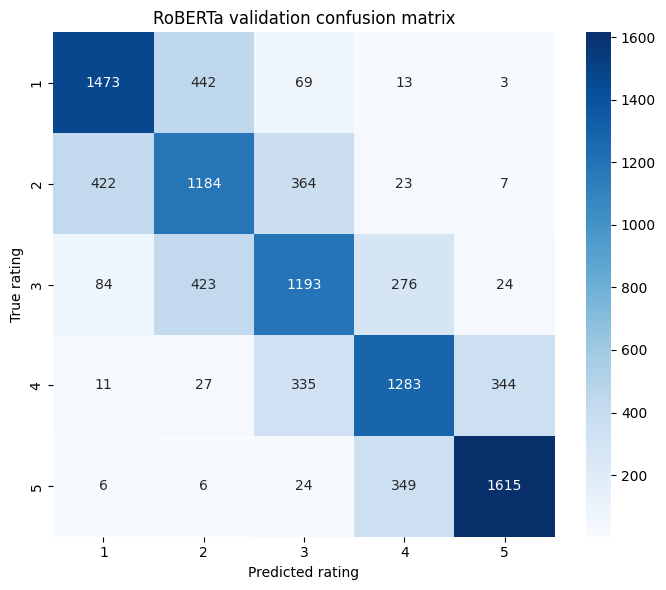

118

In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(validation_truth, validation_prediction, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(7, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted rating')
plt.ylabel('True rating')
plt.title('RoBERTa validation confusion matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=160)
plt.show()

pd.DataFrame({
    'true_rating': validation_truth,
    'predicted_rating': validation_prediction,
}).to_csv(OUTPUT_DIR / 'validation_predictions.csv', index=False)

(OUTPUT_DIR / 'validation_metrics.json').write_text(
    json.dumps(metrics, indent=2) + '\n', encoding='utf-8'
)

## Save final model artifacts

In [12]:
# KerasHub requires the adapter filename to end exactly with `.lora.h5`.
model.backbone.save_lora_weights(OUTPUT_DIR / 'roberta_lora_adapters.lora.h5')
model.save(OUTPUT_DIR / 'roberta_lora_rating_classifier.keras')
model.save_to_preset(OUTPUT_DIR / 'roberta_lora_rating_classifier_preset')

parameter_stats = {
    'lora_rank': LORA_RANK,
    'trainable_parameters': trainable_parameters,
    'total_parameters': total_parameters,
    'trainable_percentage': trainable_percentage,
}
(OUTPUT_DIR / 'parameter_stats.json').write_text(
    json.dumps(parameter_stats, indent=2) + '\n', encoding='utf-8'
)

print('Artifacts:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(OUTPUT_DIR), f'{path.stat().st_size / 1024**2:.2f} MB')

Artifacts:
checkpoints/best.weights.h5 539.75 MB
checkpoints/latest.weights.h5 539.75 MB
confusion_matrix.png 0.06 MB
logs/tensorboard/train/events.out.tfevents.1785862293.3b2d52d91d5c.22.0.v2 20.57 MB
logs/tensorboard/validation/events.out.tfevents.1785869533.3b2d52d91d5c.22.1.v2 0.00 MB
logs/training.csv 0.00 MB
parameter_stats.json 0.00 MB
roberta_lora_adapters.lora.h5 13.66 MB
roberta_lora_rating_classifier.keras 541.18 MB
roberta_lora_rating_classifier_preset/assets/tokenizer/merges.txt 0.44 MB
roberta_lora_rating_classifier_preset/assets/tokenizer/vocabulary.json 0.99 MB
roberta_lora_rating_classifier_preset/config.json 0.00 MB
roberta_lora_rating_classifier_preset/metadata.json 0.00 MB
roberta_lora_rating_classifier_preset/model.weights.h5 473.63 MB
roberta_lora_rating_classifier_preset/preprocessor.json 0.00 MB
roberta_lora_rating_classifier_preset/task.json 0.00 MB
roberta_lora_rating_classifier_preset/task.weights.h5 539.75 MB
roberta_lora_rating_classifier_preset/tokenizer.j

## Notes for the next stage

- Select the model by validation micro F1; use macro F1 to diagnose minority/adjacent-rating behaviour.
- Do not tune against the official test set.
- If GPU memory is exhausted, lower `PER_REPLICA_BATCH_SIZE` from 8 to 4; keep `MAX_LENGTH=256` when possible.
- If training is stable but underfits, compare 3 versus 4 epochs in a controlled run.
- A future controlled comparison should use this LoRA run against full RoBERTa fine-tuning with the same split, input, seed, and sequence length.
- LoRA is successful when validation performance remains close to full fine-tuning while the trainable parameter percentage and adapter size are much smaller.